# Final Project Assignment 1

### CSCI 5612 - Machine Learning for Data Science
### Drake Miller III

In this notebook, I will gather data from the Zwicky Transient Facility (ZTF) using an API. The data will then be cleaned and converted into a pandas dataframe for future machine learning analysis.

### 1.) Gather data

In [1]:
#import relevant packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#used for pulling ZTF data from API

import lsdb 
import hats
import requests
from io import StringIO
from astropy.table import Table

In [2]:
#use URL to access transient catalog, lightcurve, and image data 

#transients_path = ("s3://ipac-irsa-ztf/ztf/enhanced/dr24/objects/hats") #transient catalog data
lightcurves_path = ("s3://ipac-irsa-ztf/ztf/enhanced/dr24/lc/hats") #transient lightcurve data
#images_path = ("https://irsa.ipac.caltech.edu/ibe/search/ztf/products/sci") #image data

#transients = lsdb.read_hats(transients_path)
#transients.columns

lightcurves = lsdb.read_hats(lightcurves_path)
lightcurves = lsdb.open_catalog(lightcurves_path)
print(lightcurves.npartitions)
print(lightcurves.columns)

12485
Index(['objectid', 'filterid', 'objra', 'objdec', 'lightcurve'], dtype='object')


In [3]:
#examine one lightcurve data point

lc_sample = lightcurves.head(3)

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
lc_sample["lightcurve"].iloc[2]

,hmjd,mag,magerr,clrcoeff,catflags
0,58384.36177,18.126699,0.030027,-0.070279,0
1,58427.33331,18.178541,0.031089,-0.069309,0
...,...,...,...,...,...
43,60235.35815,18.143246,0.030360,-0.091248,0
44,60238.35307,18.151487,0.030528,-0.070024,0


In [5]:
#create a function that cleans the data and extracts useful lightcurve info

def lc_data(lc):

    ### lc = light curve input data ###

    #clean data
    lc = lc.sort_values('hmjd') #sort chronologically by observation time
    good_data = (np.isfinite(lc['hmjd']) & np.isfinite(lc['mag']) & np.isfinite(lc['magerr']) & (lc['catflags'] == 0)) #choose finite, non-nan, quality observations from the data to keep
    clean_lc = lc[good_data]

    if len(clean_lc) <= 1:
        return None #do not use lightcurves with only one observation

    #extract useful quantities
    time = clean_lc['hmjd'].to_numpy() #observation time in units of Heliocentric Modified Julian Days
    time = (time - time[0])*(24)*(60)*(60) #observations time in units of seconds, starting from t=0s
    mag = clean_lc['mag'].to_numpy() #apparent magnitude
    magerr = clean_lc['magerr'].to_numpy() #apparent magnitude uncertainty
    flux = 10**(-0.4*(mag+48.60)) #flux in erg/cm^2
    fluxerr = (np.log(10)/2.5)*flux*magerr #propagated flux uncertainty in erg/cm^2

    #convert data into useful ML dataset features
    features = {} #empty dictionary that will hold features for the final project

    dt = np.diff(time) #time difference
    features['n_obs'] = len(mag) #number of observations for this transient
    features['total_time'] = np.max(time) - np.min(time) #total observation time of this transient in seconds
    features['med_cadence'] = np.median(dt) #median observation time cadence in seconds
    features['min_cadence'] = np.min(dt) #minimum observation time in seconds
    features['max_cadence'] = np.max(dt) #maximum observation time in seconds

    features['mean_mag'] = np.mean(mag) #mean magnitude
    features['median_mag'] = np.median(mag) #median magnitude
    features['mean_magerr'] = np.mean(magerr) #mean magnitude uncertainty
    features['median_magerr'] = np.median(magerr) #median magnitude uncertainty
    features['std_mag'] = np.std(mag) #standard deviation of magnitude
    features['min_mag'] = np.min(mag) #minimum magnitude
    features['max_mag'] = np.max(mag) #maximum magnitude
    features['mag_amplitude'] = np.max(mag) - np.min(mag) #full amplitude of observation
    
    features['mean_flux'] = np.mean(flux) #mean flux
    features['median_flux'] = np.median(flux) #median flux
    features['mean_fluxerr'] = np.mean(fluxerr) #mean flux uncertainty
    features['median_fluxerr'] = np.median(fluxerr) #median flux uncertainty
    features['std_flux'] = np.std(flux) #standard deviation of flux
    features['min_flux'] = np.min(flux) #minimum magnitude
    features['min_flux_ind'] = np.argmin(flux) #minimum flux index
    features['max_flux'] = np.max(flux) #maximum flux
    features['max_flux_ind'] = np.argmax(flux) #maximum flux index
    features['flux_amplitude'] = np.max(flux) - np.min(flux) #full amplitude of observation
    features['flux_ratio'] = np.max(flux)/np.min(flux) #flux ratio
    features['frac_flux'] = (np.max(flux) - np.min(flux))/np.median(flux) #fractional flux increase

    peak_ind = np.argmax(flux)
    features['peak_time'] = time[peak_ind] #transient peak time
    features['rise_time'] = time[:peak_ind + 1] #transient rise time
    features['decay_time'] = time[peak_ind:] #transient decay time
    features['rise_flux'] = flux[:peak_ind + 1] #transient flux rise
    features['decay_flux'] = flux[peak_ind:] #transient flux decay
    
    return features

In [6]:
#define a function that extracts the lightcurve features via partitions

def process_partition(df):

    ### df = pandas partition filled with lightcurves ###

    filter_map = {1: 'g', 2: 'r', 3: 'i'} #g, r, i, photometric bands
    rows = []
    for _, row in df.iterrows():
        features = lc_data(row['lightcurve']) #extract lightcurve features
        if features is None: 
            continue #for lightcurves without enough data

        features = {'objectid': row['objectid'], 'ra': row['objra'], 'dec': row['objdec'], 'filterid': row['filterid'], 
                    'band': filter_map.get(row['filterid']), **features} #add objectid, ra, dec, and filterid to the existing features dict
        rows.append(features)

    return pd.DataFrame(rows)

In [7]:
#test the functions using a sample of lightcurve data

test = lightcurves.head(10)
test_features = process_partition(test)
print(test_features.shape)
print(test_features.dtypes)
test_features.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

(8, 35)
objectid        int64
ra            float64
               ...   
rise_flux      object
decay_flux     object
Length: 35, dtype: object


,objectid,ra,dec,filterid,band,n_obs,total_time,med_cadence,min_cadence,max_cadence,...,max_flux,max_flux_ind,flux_amplitude,flux_ratio,frac_flux,peak_time,rise_time,decay_time,rise_flux,decay_flux
0,402214400001930,45.001633,0.003649,2,r,3,6.393993e+07,3.196996e+07,5867593.344,5.807234e+07,...,2.134144e-28,1,1.403373e-28,2.920402,1.706722,5.867593e+06,"[0.0, 5867593.344000424]","[5867593.344000424, 63939929.47200006]","[8.222624e-29, 2.1341437e-28]","[2.1341437e-28, 7.3077046e-29]"
1,1447107200003291,44.996162,0.005613,1,g,43,1.601848e+08,1.256878e+05,38.880,6.333766e+07,...,2.209760e-27,31,3.495426e-28,1.187904,0.174901,6.367735e+07,"[0.0, 3712741.0559998825, 3970342.6560000284, ...","[63677354.687999815, 64457588.15999993, 644576...","[2.0385456e-27, 1.9434965e-27, 1.9929904e-27, ...","[2.2097598e-27, 1.922401e-27, 2.021739e-27, 1...."
2,1447207200005775,44.996151,0.005617,2,r,49,1.613918e+08,1.714271e+05,38.016,7.092415e+07,...,3.644916e-27,30,4.027609e-28,1.124226,0.116275,3.722814e+07,"[0.0, 2591352.000000025, 5787828.864000016, 59...","[37228139.99999987, 39389873.1840001, 39389912...","[3.3736723e-27, 3.5471774e-27, 3.4140802e-27, ...","[3.6449156e-27, 3.2702267e-27, 3.4098994e-27, ..."
3,402314400002005,44.996151,0.005628,3,i,90,1.205309e+08,3.458143e+05,79038.720,2.153258e+07,...,4.298699e-27,20,4.963380e-28,1.130534,0.121411,2.445885e+07,"[0.0, 176217.12000011466, 430221.88800028525, ...","[24458851.584000327, 24719933.375999935, 24979...","[3.9588973e-27, 4.0506513e-27, 3.9913692e-27, ...","[4.2986987e-27, 4.0302977e-27, 4.18626e-27, 4...."
4,402214400001906,44.996151,0.005630,2,r,429,2.288630e+08,1.732247e+05,77.760,1.601017e+07,...,3.794720e-27,226,6.848890e-28,1.220233,0.200403,7.488982e+07,"[0.0, 347313.3119997801, 1468697.1839997685, 1...","[74889815.32799962, 74896468.9919997, 74980389...","[3.406262e-27, 3.4318188e-27, 3.4261566e-27, 3...","[3.7947202e-27, 3.5825286e-27, 3.344051e-27, 3..."


In [40]:
#compute the original sky positions data

original_sky = (lightcurves.partitions[:10][['objectid', 'objra', 'objdec']].compute())

Computing Catalog:   0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
#run this algorithm for the entire DR24 survey using Dask/LSDB

meta = test_features.iloc[0:0].copy() #use the test as metadata for Dask
ml_data = lightcurves.map_partitions(process_partition, meta=meta) #extracted features, but NOT computed yet (lazy); DO NOT COMPUTE

In [9]:
#choose 10 partitions to compute

#ml_sample_inds = np.sort(np.random.choice(lightcurves.npartitions, 1, replace=False)) #10 random partitions, keep it to < 30 or so (about 1 hour of computing time)
ml_sample = ml_data.partitions[:10]
start = time.time() #start timer
ml_df = ml_sample.compute() #compute 10-partition sample
elapsed = time.time() - start #compute total elapsed time of computation

print(f"10 partitions: {elapsed:.1f} seconds") #print total time in seconds
print(f"Rows produced: {len(ml_df)}") #print length of dataframe

Computing Catalog:   0%|          | 0/20 [00:00<?, ?it/s]

10 partitions: 1662.0 seconds
Rows produced: 2212201


In [ ]:
#compute the original sky positions data

original_sky = (lightcurves.partitions[:10][['objectid', 'objra', 'objdec']].compute())

In [43]:
len(og_ra)

3541887

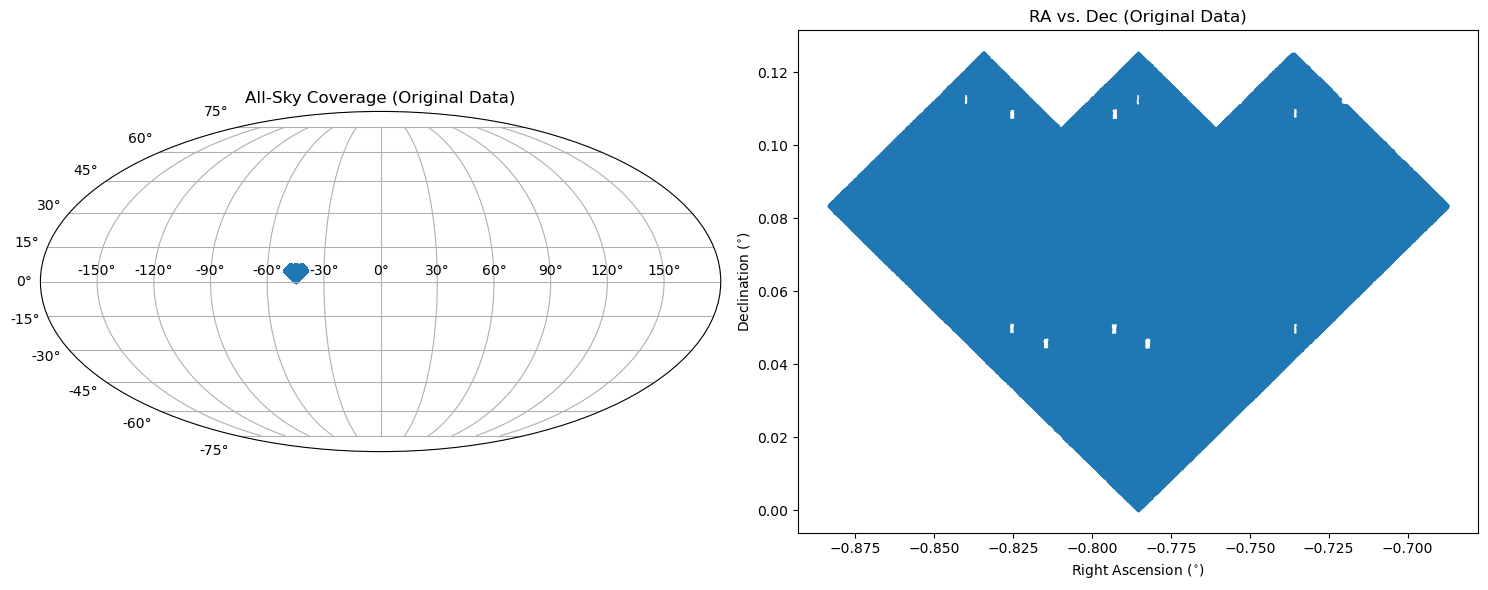

In [143]:
#plot dec vs. ra on the sky for the original 10 partitions without cleaning

og_sky_data = original_sky.drop_duplicates(subset='objectid') #drop duplicate data

# convert RA and Dec from degrees to radians
og_ra = np.radians(og_sky_data['objra'].values)
og_dec = np.radians(og_sky_data['objdec'].values)

og_ra = -og_ra #reverse ra for convention

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='mollweide') #all-sky projection
ax1.scatter(og_ra, og_dec, s=2, alpha=0.5)
ax1.grid(True)
ax1.set_title('All-Sky Coverage (Original Data)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(og_ra, og_dec, s=2, alpha=0.5)
ax2.set_xlabel('Right Ascension ' + r'$(^{\circ})$')
ax2.set_ylabel('Declination ' + r'$(^{\circ})$')
ax2.set_title('RA vs. Dec (Original Data)')

fig.tight_layout()
fig.savefig('og_sky_pos.png')

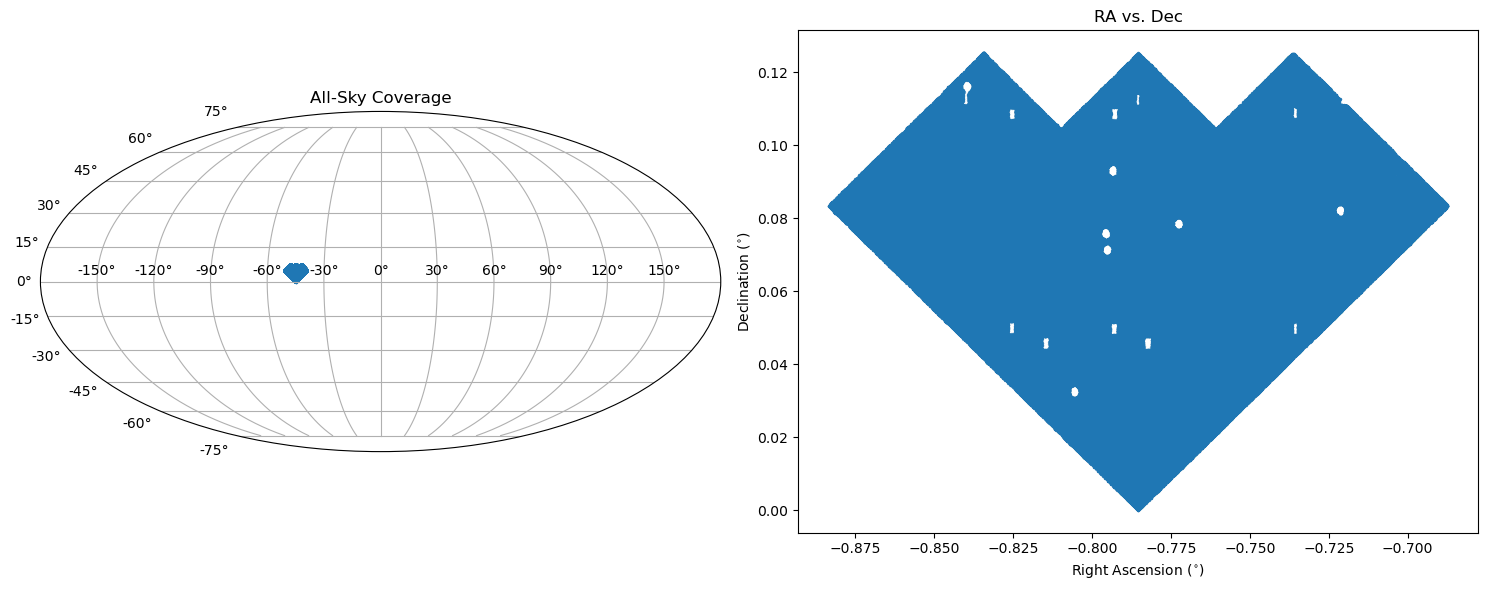

In [144]:
#plot dec vs. ra on the sky for the 10 cleaned partitions

sky_data = ml_df.drop_duplicates(subset='objectid') #drop duplicate data

# convert RA and Dec from degrees to radians
ra = np.radians(sky_data['ra'].values)
dec = np.radians(sky_data['dec'].values)

ra = -ra #reverse ra for convention

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='mollweide') #all-sky projection
ax1.scatter(ra, dec, s=2, alpha=0.5)
ax1.grid(True)
ax1.set_title('All-Sky Coverage')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(ra, dec, s=2, alpha=0.5)
ax2.set_xlabel('Right Ascension ' + r'$(^{\circ})$')
ax2.set_ylabel('Declination ' + r'$(^{\circ})$')
ax2.set_title('RA vs. Dec')

fig.tight_layout()
fig.savefig('sky_pos.png')

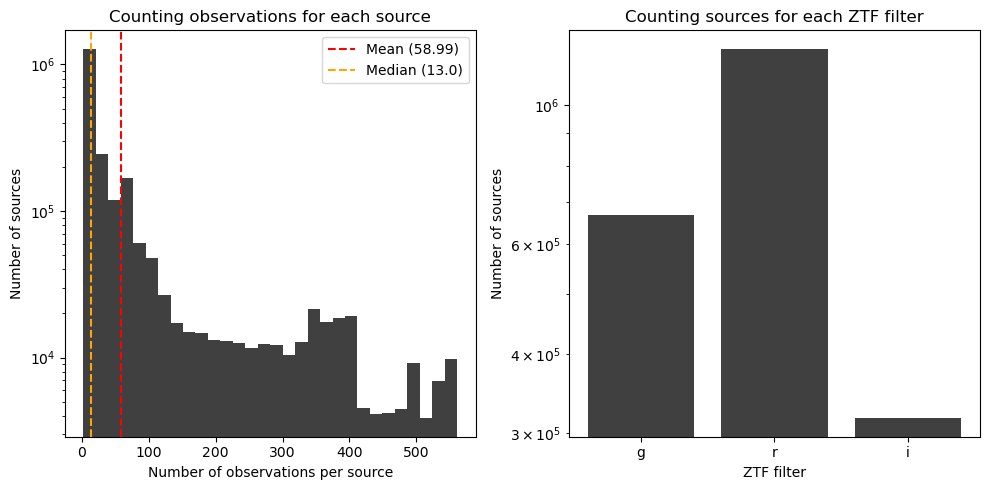

In [145]:
#plot a histogram showing the number of observations for each source

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.hist(ml_df['n_obs'], bins=30, color='black', alpha=0.75)
ax1.axvline(np.mean(ml_df['n_obs']), color='red', linestyle='--', label='Mean (' + str(round(np.mean(ml_df['n_obs']), 2)) + ')')
ax1.axvline(np.median(ml_df['n_obs']), color='orange', linestyle='--', label='Median (' + str(round(np.median(ml_df['n_obs']), 2)) + ')')
ax1.set_xlabel('Number of observations per source')
ax1.set_ylabel('Number of sources')
ax1.set_yscale('log')
ax1.set_title('Counting observations for each source')
ax1.legend(loc='best')

filter_counts = ml_df['filterid'].value_counts()
ax2.bar(filter_counts.index, filter_counts.values, color='black', alpha=0.75)
ax2.set_xlabel('ZTF filter')
ax2.set_xticks([1, 2, 3], ['g', 'r', 'i'])
ax2.set_ylabel('Number of sources')
ax2.set_yscale('log')
ax2.set_title('Counting sources for each ZTF filter')

fig.tight_layout()
fig.savefig('n_obs_hist.png')

In [95]:
#pull a few sources from partition 0

example = lightcurves.partitions[0].head(20)

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

In [99]:
#find which lightcurves have more observations and choose one

example['n_obs'] = example['lightcurve'].apply(len)
example[['objectid', 'filterid', 'n_obs']].sort_values('n_obs', ascending=False)
example = example.loc[example['n_obs'].idxmax()]

example_id = example['objectid']
lc = example['lightcurve']

In [102]:
#clean data the same as before

lc = lc.sort_values('hmjd')
good_data = (np.isfinite(lc['hmjd']) & np.isfinite(lc['mag']) & np.isfinite(lc['magerr']) & (lc['catflags'] == 0))
lc_clean = lc[good_data]

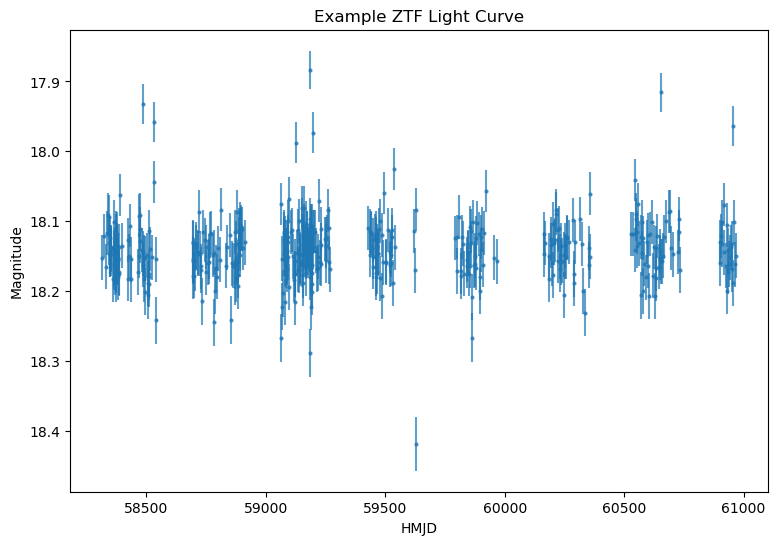

In [146]:
#plot the example light curve

plt.figure(figsize=(9, 6))
plt.errorbar(lc_clean['hmjd'], lc_clean['mag'], yerr=lc_clean['magerr'], fmt='.', markersize=4, alpha=0.7)
plt.xlabel('HMJD')
plt.ylabel('Magnitude')
plt.title(f'Example ZTF Light Curve')
plt.gca().invert_yaxis() #magnitudes are inverted brightness
plt.savefig('ex_lightcurve.png')

In [124]:
#extract and flatten the rise and decay times

rise_times = np.concatenate(ml_df['rise_time'].values)
decay_times = np.concatenate(ml_df['decay_time'].values)

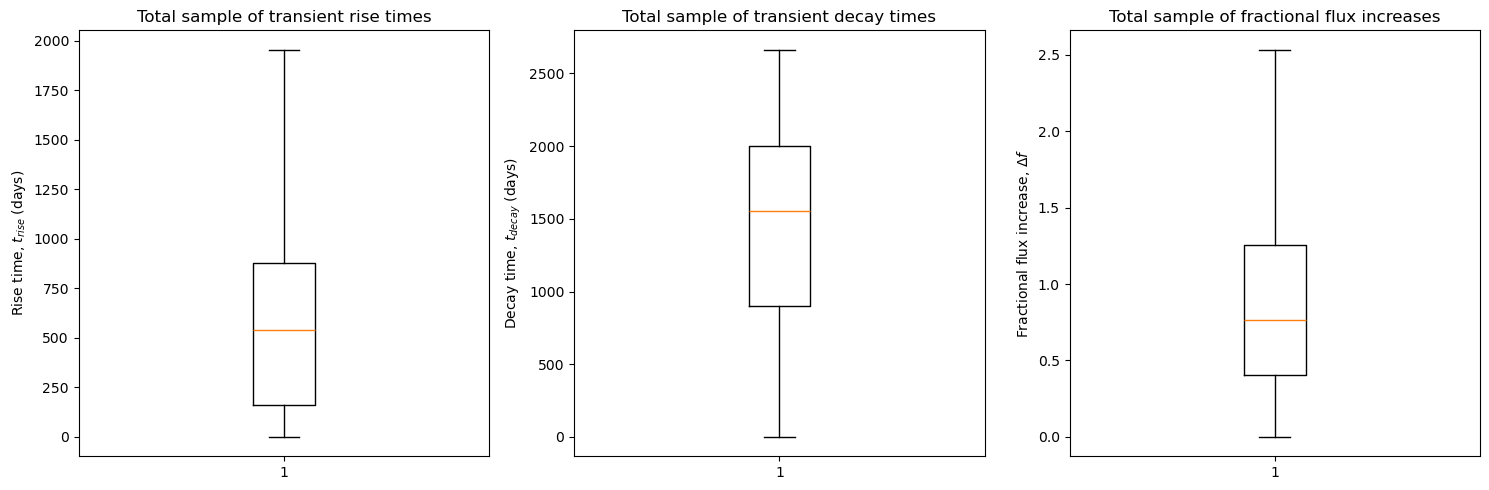

In [147]:
#create boxplots for the total sample of rise and decay times

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))

ax1.boxplot(rise_times/86400, showfliers=False)
ax1.set_ylabel('Rise time, ' + r'$t_{rise}$' + ' (days)')
ax1.set_title('Total sample of transient rise times')

ax2.boxplot(decay_times/86400, showfliers=False)
ax2.set_ylabel('Decay time, ' + r'$t_{decay}$' + ' (days)')
ax2.set_title('Total sample of transient decay times')

ax3.boxplot(ml_df['frac_flux'], showfliers=False)
ax3.set_ylabel('Fractional flux increase, ' + r'$\Delta f$')
ax3.set_title('Total sample of fractional flux increases')

fig.tight_layout()
fig.savefig('transient_boxplots.png')

### Image data (for later)

In [9]:
#use URL to access transient image data

params = {"FORMAT": "csv"}

response = requests.get(images_path, params=params)
response.raise_for_status()

images = pd.read_csv(StringIO(response.text))

images.head()

,"<?xml version=""1.0"" encoding=""utf-8""?>"
0,"<VOTABLE version=""1.3"" xmlns:xsi=""http://www.w..."
1,<DESCRIPTION>Caltech/IPAC-IRSA Image Backend...
2,"<RESOURCE type=""results"">"
3,"<INFO name=""QUERY_STATUS"" value=""ERROR"">Us..."
4,</RESOURCE>


In [13]:
#using a sample of data, create an astropy table of ra/dec sky positions to use for image cutouts

sample = transients.head(1000) #take only the first 1000 objects
sky_positions = Table() #create an astropy table
sky_positions["ra"] = sample["ra"] #create and populate the right ascension column
sky_positions["dec"] = sample["dec"] #create and populate the declination column

sky_positions

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

ra,dec
float64,float64
44.6067206,1.2436736
44.6066019,1.2436912
44.6067067,1.2443114
44.6060791,1.2461088
44.6010665,1.2464787
44.6040686,1.2454352
44.6058883,1.2470843
44.614772,1.2416056
44.6148192,1.2417164
